# RAG, векторная база и память агента


**Ключ** OpenRouter: локально файл `.env` рядом с ноутбуком, в Kaggle секрет `OPENROUTER_API_KEY` (Add-ons, Secrets, галочка подключения, перезапуск сессии). 


**Ссылка** на прокси: локально файл `.env` рядом с ноутбуком, нужно для доступа к OpenRouter


**Данные**: папка `data` рядом с ноутбуком.


**Milvus** в Docker: в папке семинара лежит `docker-compose.yml`, команда `docker compose up -d` поднимает базу на `localhost:19530`. Первый запуск скачивает образ, около гигабайта, поэтому сделайте это до семинара. Если Docker поставить нельзя (Kaggle, Colab), в README есть раздел «Нет Docker».


В данных лежит готовый файл эмбеддингов корпуса `embeddings_512.npz`. С ним второй спринт занимает секунды. Без него те же векторы посчитаются через API за цент и минут двадцать: так было у нас при подготовке, и на общей сети аудитории будет не быстрее.

In [5]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

In [6]:
USE_PROXY = True
# OpenRouter не пускает из РФ
# Поэтому поднял небольшой прокси


In [7]:
if USE_PROXY:
    PROXY_URL = os.getenv("PROXY_URL")
    CHAT_URL = PROXY_URL + "chat/completions"
    EMBED_URL = PROXY_URL + "embeddings"
else:
    CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
    EMBED_URL = "https://openrouter.ai/api/v1/embeddings"

In [8]:

HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar02-data"), Path("/kaggle/input/seminar02-data/data")]
             if (p / "corpus_2026.jsonl").exists()), Path("data"))
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8-sig").splitlines() if line.strip()]

In [53]:
msg = chat([{"role": "user", "content": "Ответь одним словом: какого цвета небо?"}], MODELS["cheap"], tag="hello")
msg["content"], ledger.calls[-1]

('Синего.',
 {'tag': 'hello',
  'model': 'gpt-4o-mini',
  'prompt': 18,
  'completion': 4,
  'cost': 5.1e-06,
  'seconds': 1.82})

In [3]:
import arxiv

search = arxiv.Search(query="RAG", max_results=5,
                           sort_by=arxiv.SortCriterion.Relevance)

In [9]:
search

arxiv.Search(query='RAG', id_list=[], max_results=5, sort_by=<SortCriterion.Relevance: 'relevance'>, sort_order=<SortOrder.Descending: 'descending'>)

### Сбор корпуса

In [1]:
from download_papers import download_papers
from build_corpus import build_corpus


In [2]:
manifest = download_papers("retrieval augmented generation", max_results=15)

In [ ]:
corpus = build_corpus(manifest)

Building corpus:   0%|          | 0/15 [00:00<?, ?it/s]Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\anaconda3\envs\agents\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\anaconda3\envs\agents\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\anaconda3\envs\agents\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xad in position 12: invalid start byte
Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\anaconda3\envs\agents\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\anaconda3\envs\agents\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\anaconda3\envs\agents\Lib\subprocess.py", line 1599, in _readerthrea


✅ Корпус создан: 15 статей из 15


In [4]:
print(arxiv.__version__)

4.0.1


In [9]:
import json

with open("data/structured_corpus.jsonl", "r", encoding="utf-8") as f:
    corpus = [json.loads(line) for line in f if line.strip()]

print(len(corpus), sum(len(p["text"]) for p in corpus))

15 1032828


In [10]:
# Норм вопросы
answer_true = ["q-1", "q-6", "q-10", "q-17", "q-20", "q-26", "q-30", "q-36", "q-41", "q-42", "q-47", "q-62", "q-67", "q-71", "q-73", "q-83", "q-87", "q-92", "q-99", "q-100", "q-105", "q-108", "q-113", "q-119", "q-123", "q-127", "q-130", "q-137", "q-143", "q-148"]
answer_false = ["nq-2", "nq-9", "nq-12", "nq-17", "nq-34", "nq-37", "nq-44", "nq-52", "nq-61", "nq-66"]

### Проверка evidence

In [27]:
import re, unicodedata
import pandas as pd
from rapidfuzz import fuzz        # pip install rapidfuzz — быстрый нечёткий поиск подстроки (C++)

def norm_loose(text):
    """Мягкая нормализация: убирает то, чем PDF-текст отличается от того, что написал человек в evidence."""
    text = unicodedata.normalize("NFKC", str(text))        # лигатуры ﬁ→fi, типографские кавычки и тире → обычные
    text = text.lower()
    text = re.sub(r"(\w)-\s*\n?\s*(\w)", r"\1\2", text)    # перенос строки: "retrie- val" → "retrieval"
    text = re.sub(r"[#*_`>|\[\]()]", " ", text)            # markdown-разметка
    text = re.sub(r"[^\w\s]", " ", text)                   # вся остальная пунктуация
    return " ".join(text.split())                          # схлопываем пробелы и переводы строк

def check_evidence(corpus, tasks, fuzzy_threshold=85):
    """
    Для каждого вопроса ищет evidence в тексте ЕГО документа (по url), до всякой нарезки.
    status: exact  — нормализованное evidence найдено дословно
            fuzzy  — найдено похожее место (partial_ratio >= порога, 0..100)
            missing — нет ни там, ни там → проблема в корпусе/разметке, а не в нарезке
    """
    docs = {d["url"]: (d, norm_loose(d["text"])) for d in corpus}
    rows = []
    for t in tasks:
        if not t.get("evidence"):                          # nq-* : evidence нет по определению
            continue
        ev = norm_loose(t["evidence"])
        doc, text = docs.get(t["url"], (None, ""))
        exact = ev in text
        score = pos = None
        if not exact and text:
            m = fuzz.partial_ratio_alignment(ev, text)     # лучшее выравнивание evidence внутри документа
            score, pos = m.score, m.dest_start
        status = "exact" if exact else ("fuzzy" if score is not None and score >= fuzzy_threshold else "missing")
        best_other = None
        if status == "missing":                            # вдруг вопрос привязан не к тому документу
            best_other = max(((fuzz.partial_ratio(ev, tx), d["title"][:40])
                              for u, (d, tx) in docs.items() if u != t["url"]), default=None)
        rows.append({"id": t["id"], "title": t["title"][:40], "status": status,
                     "score": round(score, 1) if score is not None else (100.0 if exact else None),
                     "answer_in_doc": norm_loose(t["answer"]) in text,
                     "doc_found": doc is not None,
                     "snippet": text[pos:pos + 120] if pos is not None else "",
                     "best_other_doc": best_other})
    return pd.DataFrame(rows)

corpus, tasks = load_jsonl("structured_corpus.jsonl"), load_jsonl("questions.jsonl")
tasks = [t for t in tasks if t["id"] in set(answer_true)]     # только отвечаемые
res = check_evidence(corpus, tasks)
print(res["status"].value_counts())
res[res["status"] != "exact"][["id", "title", "status", "score", "answer_in_doc", "snippet", "best_other_doc"]]

status
exact    29
fuzzy     1
Name: count, dtype: int64


,id,title,status,score,answer_in_doc,snippet,best_other_doc
2,q-10,Intelligent Interaction Strategies for C,fuzzy,94.5,False,sensory systems acquire information at approx...,None


## Спринт 1. Корпус и нарезка

Корпус это 28 обзорных страниц Википедии про 2026 год, 830 тысяч символов. Вопросы те же, что в первой домашке: 124 штуки, на которых Sonnet без инструментов не отвечает. У каждого вопроса есть поле `evidence`, исходная строка с ответом, поэтому мы точно знаем, какой кусок верный, и сможем считать качество поиска без ручной разметки.

Страница устроена как список датированных событий: одна строка, одно событие. Отсюда два способа резать. Наивный: по 400 символов, не глядя на границы. По структуре: одна строка это один кусок, а заголовок раздела (месяц) едет с куском как метаданные.

Дырка: нарезка по строкам. Чекпоинт: число кусков в обеих нарезках и пример факта, который наивная нарезка разорвала пополам.

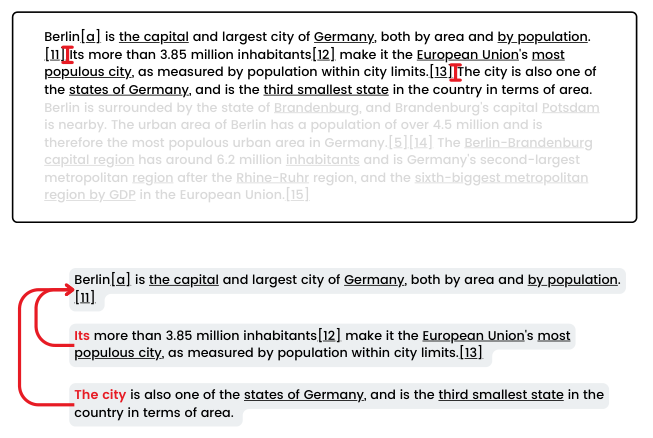

*Günther et al., 2024. Кусок без контекста: во втором и третьем предложении слова «Берлин» уже нет. Поэтому к тексту куска мы приписываем название страницы*

In [81]:
corpus, tasks = load_jsonl("structured_corpus.jsonl"), load_jsonl("questions.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), tasks[0]

(15,
 1032828,
 225,
 {'id': 'q-0',
  'source': 'corpus',
  'question': 'What does AR-RAG retrieve at each generation step?',
  'answer': 'Patch-level k-NN retrievals.',
  'evidence': 'Unlike prior methods that perform a single, static retrieval before generation and condition the entire generation on fixed reference images, AR-RAG performs context-aware retrievals at each generation step, using prior-generated patches as queries to retrieve and incorporate the most relevant patch-level visual references, enabling the model to respond to evolving generation needs while avoiding limitations (e.g., over-copying, stylistic bias, etc.) prevalent in existing methods.',
  'title': 'AR-RAG: Autoregressive Retrieval Augmentation for Image Generation',
  'url': 'http://arxiv.org/abs/2506.06962v3',
  'agent_ok': False})

Все вопросы использовать не будем

In [29]:
allowed_ids = set(answer_true) | set(answer_false)
tasks = [t for t in tasks if t.get("id") in allowed_ids]
print("После фильтрации:", len(tasks))

После фильтрации: 40


In [30]:

import re
from copy import deepcopy

_HEADER_RE   = re.compile(r'^(#{1,6})\s+(.*)$')
_SKIP_BLOCK  = re.compile(
    r'^(ACM Reference Format|Additional Key Words|Keywords|References|'
    r'Bibliography|CCS Concepts|Author Keywords)\b', re.I,
)
_AFFIL_RE = re.compile(
    r'\b(University|Institute|Research|Laboratory|College|Academy|Inc\.|Ltd\.)\b',
    re.I,
)


def _is_author_or_affil(para: str) -> bool:
    if _AFFIL_RE.search(para):
        return True
    words = para.split()
    if len(words) < 25 and para.count(',') >= 2 and not para.endswith('.'):
        caps = sum(1 for w in words if w[:1].isupper())
        return caps >= len(words) * 0.5
    return False


def clean_text(text: str) -> str:
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    # 1) markdown-заголовок всегда отдельный абзац, иначе он склеится со следующей строкой
    text = re.sub(r'(?m)^[ \t]*(#{1,6}[ \t]+.*?)[ \t]*$', r'\n\n\1\n\n', text)
    # 2) пустая строка(и) = граница абзаца; прячем её за маркер \x00, чтобы шаг 3 её не тронул
    text = re.sub(r'[ \t]*\n(?:[ \t]*\n)+[ \t]*', '\x00', text)
    # 3) оставшийся одиночный \n = перенос строки внутри абзаца → пробел
    text = re.sub(r'[ \t]*\n[ \t]*', ' ', text)
    text = text.replace('\x00', '\n\n')
    # 4) схлопываем пробелы
    return re.sub(r'[ \t]+', ' ', text).strip()


def clean_doc(doc: dict, *, drop_references: bool = True) -> dict:
    """
    Возвращает НОВЫЙ doc с очищенным text.
    Опционально отрезает блок References и выкидывает авторов/аффилиации.
    """
    doc = deepcopy(doc)
    text = clean_text(doc.get("text", ""))

    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    kept: list[str] = []
    skip_until_blank = False
    in_references = False

    for para in paragraphs:
        # markdown-заголовок?
        m = _HEADER_RE.match(para)
        if m:
            title = m.group(2).strip().strip('*').strip()
            if drop_references and re.fullmatch(r'(References|Bibliography)', title, re.I):
                in_references = True
                continue
            if in_references and m.group(1):  # новый раздел после References
                in_references = False
            skip_until_blank = bool(_SKIP_BLOCK.match(title))
            kept.append(para)
            continue

        if in_references:
            continue

        if skip_until_blank:
            # выход из мусорного блока: длинный абзац или новый заголовок
            if len(para) > 200:
                skip_until_blank = False
            else:
                continue

        if _SKIP_BLOCK.match(para):
            skip_until_blank = True
            continue

        if _is_author_or_affil(para) and len(para) < 200:
            continue

        kept.append(para)

    doc["text"] = "\n\n".join(kept)
    return doc


def preprocess(corpus: list[dict], **kw) -> list[dict]:
    return [clean_doc(d, **kw) for d in corpus]

In [ ]:

import re

_HEADER_RE   = re.compile(r'^(#{1,6})\s+(.*)$')
_SENT_SPLIT  = re.compile(r'(?<=[.!?])\s+(?=[A-Z(])')


def _meta(doc, section=""):
    return {
        "doc_id": doc["doc_id"],
        "title":  doc["title"],
        "url":    doc["url"],
        "section": section,
    }


def chunk_chars(doc, size=800, overlap=120):
    """Слепое окно по символам. По умолчанию работаем по предложениям,
    чтобы не рвать слова на стыке чанков."""
    if size <= 0:
        raise ValueError("size must be > 0")
    if not (0 <= overlap < size):
        raise ValueError("overlap must be in [0, size)")

    text = doc["text"]
    step = size - overlap
    out = []
    for i in range(0, len(text), step):
        piece = text[i:i + size].strip()
        if not piece:
            continue
        out.append({**_meta(doc), "text": piece})
        if i + size >= len(text):
            break
    return out


def chunk_lines(
    doc,
    *,
    max_chars: int = 900,
    min_chars: int = 200,
    overlap_chars: int = 120,
):
    """Абзацы + иерархия markdown-заголовков. Очистка уже сделана выше."""
    chunks: list[dict] = []
    h1 = h2 = h3 = ""
    buf: list[str] = []
    buf_meta: dict | None = None

    def flush():
        nonlocal buf, buf_meta
        if buf_meta is not None and buf:
            _pack(chunks, buf, buf_meta, max_chars, min_chars, overlap_chars)
        buf, buf_meta = [], None

    for para in doc["text"].split("\n\n"):
        para = para.strip()
        if not para:
            continue

        m = _HEADER_RE.match(para)
        if m:
            flush()
            level, title = len(m.group(1)), m.group(2).strip().strip('*').strip()
            if level == 1:
                h1, h2, h3 = title, "", ""
            elif level == 2:
                h2, h3 = title, ""
            else:
                h3 = title
            continue

        section = " › ".join(x for x in (h1, h2, h3) if x)
        meta = _meta(doc, section)
        if buf_meta and buf_meta["section"] != section:
            flush()
        if not buf:
            buf_meta = meta
        buf.append(para)

    flush()
    return chunks


def _pack(chunks, buf, meta, max_chars, min_chars, overlap_chars):
    text = " ".join(buf).strip()
    if not text:
        return
    sents = [s.strip() for s in _SENT_SPLIT.split(text) if s.strip()]
    pieces, cur = [], ""
    for s in sents:
        if cur and len(cur) + 1 + len(s) > max_chars:
            pieces.append(cur)
            cur = s
        else:
            cur = f"{cur} {s}".strip()
    if cur:
        pieces.append(cur)

    merged: list[str] = []
    for p in pieces:
        if merged and len(merged[-1]) < min_chars:
            merged[-1] = f"{merged[-1]} {p}"
        else:
            merged.append(p)

    for p in merged:
        chunks.append({**meta, "text": p})

In [ ]:
corpus = load_jsonl("structured_corpus.jsonl")

clean = preprocess(corpus, drop_references=True)

line_chunks = [c for p in clean for c in chunk_lines(p)]
char_chunks = [c for p in clean for c in chunk_chars(p, size=400, overlap=100)]

len(line_chunks), len(char_chunks), line_chunks[100]

(1227,
 2842,
 {'doc_id': '2504.13684v1',
  'title': 'Intelligent Interaction Strategies for Context-Aware Cognitive Augmentation',
  'url': 'http://arxiv.org/abs/2504.13684v1',
  'section': 'Intelligent Interaction Strategies for Context-Aware Cognitive Augmentation › 3.2 Preliminary Findings',
  'text': '_3.2.1 Participants’ Information Processing Strategies._ Participants processed information through multiple modalities, including text, video, and interactive displays. They used textual content for comprehension and later reference, with some reading aloud to reinforce understanding and others storing text for post-visit review. They treated video recordings as a backup for later reflection rather than an immediate resource. They captured photographs to document key information but struggled with organization and retrieval. Two of the participants (N=2/3) mentioned the intention to annotate images in real-time. Participants unconsciously collected additional information through mov

In [33]:
def torn(task):
    words = re.findall(r"\w+", task["evidence"].lower())
    head, tail = " ".join(words[:6]), " ".join(words[-6:])
    parts = [c["text"] for c in char_chunks if c["title"] == task["title"]
             and (head in " ".join(re.findall(r"\w+", c["text"].lower())) or tail in " ".join(re.findall(r"\w+", c["text"].lower())))]
    return parts if len(parts) == 2 else None

example = next(t for t in tasks if torn(t))
print("вопрос:", example["question"], "| ответ:", example["answer"])
for n, part in enumerate(torn(example), 1):
    print(f"кусок {n}: ...{part[-160:]}" if n == 1 else f"кусок {n}: {part[:160]}...")

вопрос: What are the two parallel frameworks proposed to realize AR-RAG? | ответ: DAiD and FAiD.
кусок 1: ...stic bias, etc.) prevalent in existing methods. To realize AR-RAG, we propose two parallel frameworks: (1) Distribution-Augmentation in Decoding (DAiD), a train
кусок 2: parameter-efficient fine-tuning method that progressively smooths the features of retrieved patches via multi-scale convolution operations and leverages them to...


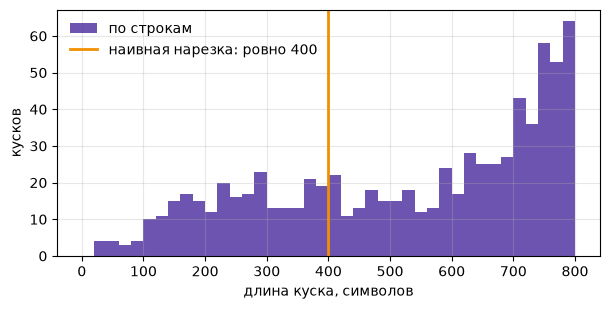

In [76]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([len(c["text"]) for c in line_chunks], bins=40, range=(0, 800), color=COLORS["violet"], alpha=0.85, label="по строкам")
ax.axvline(400, color=COLORS["amber"], lw=2, label="наивная нарезка: ровно 400")
ax.set_xlabel("длина куска, символов"); ax.set_ylabel("кусков"); ax.legend(frameon=False); ax.grid(alpha=0.3);

## Спринт 2. Эмбеддинги и кэш

Эмбеддинг текста не меняется, пока не меняются текст и модель, поэтому считать его дважды незачем. Кэш устроен просто: ключ это хэш текста, значение это вектор. Сначала в кэш загружается готовый файл из данных, потом всё, чего там нет, досчитывается через API пачками по 64 текста.

Вектор берём укороченный, 512 измерений вместо 1536: это «матрёшка» из пятой лекции, параметр `dimensions` в запросе. Ответ API втрое легче, память втрое меньше, качество почти то же. Пачка в 256 текстов на полной размерности это восемь мегабайт JSON, и на медленной сети такой запрос просто не доходит.

Дырка: `embed_cached`. Чекпоинт: матрицы векторов для обеих нарезок и вопросов и строка в леджере с ценой.

In [35]:
EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed("emb_cache.npz", keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

load_cache()

9411

In [36]:
def embed_cached(texts):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB)) #set нельзя т.к. нет порядка
    for i in range(0, len(missing), 64):
        batch = missing[i:i+64]
        for text, vector in zip(batch, embed_batch(batch)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)

    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
        


In [37]:
def emb_text(chunk):
    return f"{chunk['title']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
save_cache()
line_vecs.shape, char_vecs.shape, q_vecs.shape

((1227, 512), (2842, 512), (40, 512))

In [21]:
probe = embed_cached(["Apple is a big techological company in USA", "Green apple is a tasty food from the my garden", "What was the weather in Tokyo yesterday?"])
save_cache()
(probe @ probe.T).round(2), ledger.table()

(array([[1.  , 0.27, 0.01],
        [0.27, 1.  , 0.02],
        [0.01, 0.02, 1.  ]], dtype=float32),
                               calls  prompt  completion     cost
 tag   model                                                     
 embed text-embedding-3-small     48  336210           0  0.00672)

In [ ]:
X (3 * 512) @ X.T (512 * 3) = A (3 * 3)

In [56]:
probe

array([[ 0.00411923, -0.04049051, -0.03000936, ..., -0.02994833,
         0.00115186, -0.03457102],
       [ 0.00601717, -0.02115356,  0.00516629, ..., -0.0727707 ,
        -0.03333289, -0.00468553],
       [ 0.00150853, -0.05599293, -0.08824608, ..., -0.06255341,
         0.01283108, -0.01235811]], shape=(3, 512), dtype=float32)

## Спринт 3. Поиск на numpy и recall@k

Векторы нормализованы, значит косинусная близость это скалярное произведение, а близость вопроса ко всему корпусу это одно умножение матрицы на вектор. Для шести тысяч кусков этого хватает с запасом.

Качество поиска меряем отдельно от качества ответа. `recall@k` это доля вопросов, у которых верный кусок попал в первые k. Верным считаем кусок с той же страницы, в котором есть ответ и не меньше половины слов исходной строки: так наивная нарезка честно получает штраф за разорванные факты.

Дырка: `search_numpy`. Чекпоинт: кривая recall@k для двух нарезок.

In [38]:
def search_numpy(query_vec, vectors, k=5):
    sims = vectors @ query_vec
    top = np.argsort(-sims)[:k]
    return[(int(i), float(sims[i])) for i in top]


In [77]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["url"] != task["url"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(chunks, vectors, ks=(1, 3, 5, 10, 20)):
    ranked = [[i for i, _ in search_numpy(q, vectors, max(ks))] for q in q_vecs]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, [t for t in tasks if t["id"].startswith("q-")])])) for k in ks}

for i, score in search_numpy(q_vecs[0], line_vecs, 3):
    print(round(score, 3), "|", line_chunks[i]["title"], "|", line_chunks[i]["text"][:110])
tasks[0]["question"], tasks[0]["answer"]

0.657 | Engineering the RAG Stack: A Comprehensive Review of the Architecture and Trust Frameworks for Retrieval-Augmented Generation Systems | Research Areas of High Priority (1-2 Years): The most optimistic nearterm advancement is end-to-end optimizati
0.644 | Engineering the RAG Stack: A Comprehensive Review of the Architecture and Trust Frameworks for Retrieval-Augmented Generation Systems | Unity architectures that incorporate numerous advanced capabilities into coherent, powerful systems are becomi
0.64 | AR-RAG: Autoregressive Retrieval Augmentation for Image Generation | While our AR-RAG framework demonstrates strong performance across multiple benchmarks, several limitations sho


('What are the two parallel frameworks proposed to realize AR-RAG?',
 'DAiD and FAiD.')

бля тут были и из списка не отвечаемых

,по строкам,по 800 символов
1,0.37,0.23
3,0.47,0.37
5,0.50,0.47
10,0.67,0.60
20,0.67,0.63


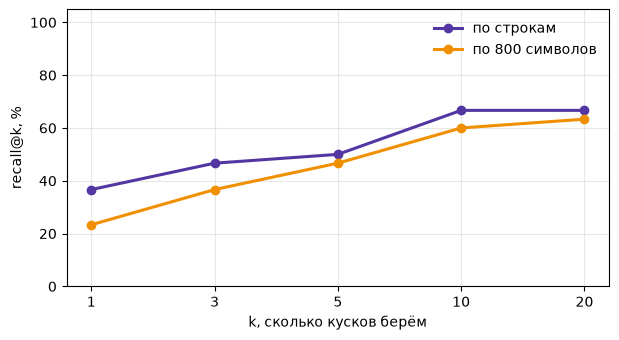

In [78]:
curves = {"по строкам": recall_curve(line_chunks, line_vecs), "по 800 символов": recall_curve(char_chunks, char_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

In [73]:
# заголовок — короткая строка; страховка, чтобы "весь документ" никогда не принимался за заголовок
def _as_header(para):
    m = _HEADER_RE.match(para)
    return m if (m and "\n" not in para and len(para) < 200) else None

# аффилиации: без re.I и без слишком общих слов; "Research" убрать совсем
_AFFIL_RE = re.compile(r'\b(University|Institute|Laboratory|College|Academy|Inc\.|Ltd\.)\b')

def clean_doc(doc: dict, *, drop_references: bool = True, trace: list | None = None) -> dict:
    doc = deepcopy(doc)
    text = clean_text(doc.get("text", ""))
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    kept, skip_until_blank, in_references = [], False, False

    def drop(reason, para):
        """Запоминаем выброшенный абзац и причину (если trace передан)."""
        if trace is not None:
            trace.append((reason, para))

    for para in paragraphs:
        m = _as_header(para)
        if m:
            title = m.group(2).strip().strip('*').strip()
            if drop_references and re.fullmatch(r'(References|Bibliography)', title, re.I):
                in_references = True
                drop("заголовок References", para); continue
            in_references = False                         # любой другой заголовок закрывает блок References
            skip_until_blank = bool(_SKIP_BLOCK.match(title))
            kept.append(para); continue
        if in_references:
            drop("внутри References", para); continue
        if re.fullmatch(r'\d{1,3}', para):                # одинокий номер страницы
            drop("номер страницы", para); continue
        if skip_until_blank:
            if len(para) > 200: skip_until_blank = False   # длинный абзац = мусорный блок кончился
            else:
                drop("хвост SKIP_BLOCK", para); continue
        if _SKIP_BLOCK.match(para):
            skip_until_blank = True
            drop("начало SKIP_BLOCK", para); continue
        if _is_author_or_affil(para) and len(para) < 200:
            drop("автор/аффилиация", para); continue
        kept.append(para)

    doc["text"] = "\n\n".join(merge_broken(kept))         # merge_broken: см. шаг 3
    return doc

def dropped_near_evidence(task, min_share=0.3):
    """Выброшенные абзацы, в которых есть заметная доля слов evidence."""
    trace = []
    clean_doc(raw_by_url[task["url"]], trace=trace)
    ev = set(norm(task["evidence"]).split())
    return [(why, p[:100]) for why, p in trace
            if len(ev & set(norm(p).split())) >= min_share * len(ev)]

def merge_broken(paragraphs):
    """Склеивает абзац с предыдущим, если тот оборвался посреди предложения
    (нет конечной пунктуации) и текущий начинается с маленькой буквы."""
    out = []
    for p in paragraphs:
        prev = out[-1] if out else ""
        if (prev and not _as_header(prev) and not _as_header(p)
                and not re.search(r'[.!?:;)\]"”]$', prev) and p[:1].islower()):
            out[-1] = f"{prev} {p}"
        else:
            out.append(p)
    return out

for tid in ("q-10", "q-73"):
    t = next(t for t in tasks if t["id"] == tid)
    print(tid, dropped_near_evidence(t))

def evidence_prefix_in(task, text):
    """Сколько первых слов evidence идёт в тексте подряд и что следует за точкой разрыва."""
    w = norm(task["evidence"]).split()
    t = " ".join(norm(text).split())
    for n in range(len(w), 0, -1):                        # ищем самый длинный префикс evidence
        if " ".join(w[:n]) in t:
            return n, len(w), " ".join(w[n:n + 6])        # (найдено слов, всего слов, слова после разрыва)
    return 0, len(w), ""

clean_by_url = {d["url"]: d for d in preprocess(corpus)}
for tid in ("q-10", "q-73"):
    t = next(t for t in tasks if t["id"] == tid)
    print(tid, evidence_prefix_in(t, clean_by_url[t["url"]]["text"]))

q-10 []
q-73 []
q-10 (8, 23, '9 bits per second cognitive processing')
q-73 (22, 26, '02 per document inference')


In [75]:
from difflib import SequenceMatcher

def snap_evidence(task, doc_text):
    """Скользящее окно по тексту статьи: ищем фрагмент, больше всего похожий на evidence.
    Возвращает (похожесть 0..1, фрагмент). Результат проверять глазами, автозамене не доверять."""
    ev, t = " ".join(task["evidence"].split()), " ".join(doc_text.split())
    n, best = len(ev), (0.0, "")
    for i in range(0, max(1, len(t) - n), max(1, n // 4)):    # шаг n/4: грубо, но быстро
        w = t[i:i + int(n * 1.3)]
        best = max(best, (SequenceMatcher(None, ev, w).ratio(), w))
    return best

t = next(t for t in tasks if t["id"] == "q-137")
print(snap_evidence(t, raw_by_url[t["url"]]["text"]))

(0.8725490196078431, 'l hints from entities. We use the knowledge graph _G_ to construct HolE embeddings for the entities and relations. ')


## Спринт 4. Milvus

Перебор на numpy честный и быстрый, но это только поиск. База добавляет то, что нужно продукту: хранение на диске, метаданные рядом с вектором, фильтры, добавление и удаление без пересборки, индекс для миллионов векторов и доступ по сети для нескольких сервисов сразу.

Milvus поднимаем так же, как его поднимают в жизни: контейнером. В папке семинара лежит `docker-compose.yml`, в нём один сервис, сам Milvus в режиме standalone со встроенным etcd и локальным хранилищем.

```
docker compose up -d        поднять, база слушает localhost:19530
docker compose ps           статус должен стать healthy
docker compose logs -f      посмотреть, что происходит внутри
docker compose down         остановить, данные останутся в томе
docker compose down -v      остановить и стереть данные
```

В боевой установке etcd и объектное хранилище (MinIO или S3) живут отдельными сервисами, а сам Milvus раскладывается на несколько узлов. Код клиента от этого не меняется: меняется только адрес в `MILVUS_URI`.

Рядом с вектором храним всё, что понадобится показать человеку и подложить модели: текст куска, страницу, раздел, ссылку. Поля, которых нет в схеме, Milvus складывает как динамические, и по ним можно фильтровать. После вставки зовём `flush`: он запечатывает сегмент, по нему строится индекс, а `row_count` в статистике становится точным.

Две дырки: загрузка кусков в коллекцию и поиск с фильтром. Чекпоинт: выдача Milvus почти полностью совпадает с перебором, фильтр по странице работает, и два замера скорости: на нашем корпусе и на корпусе, раздутом до двухсот тысяч векторов.

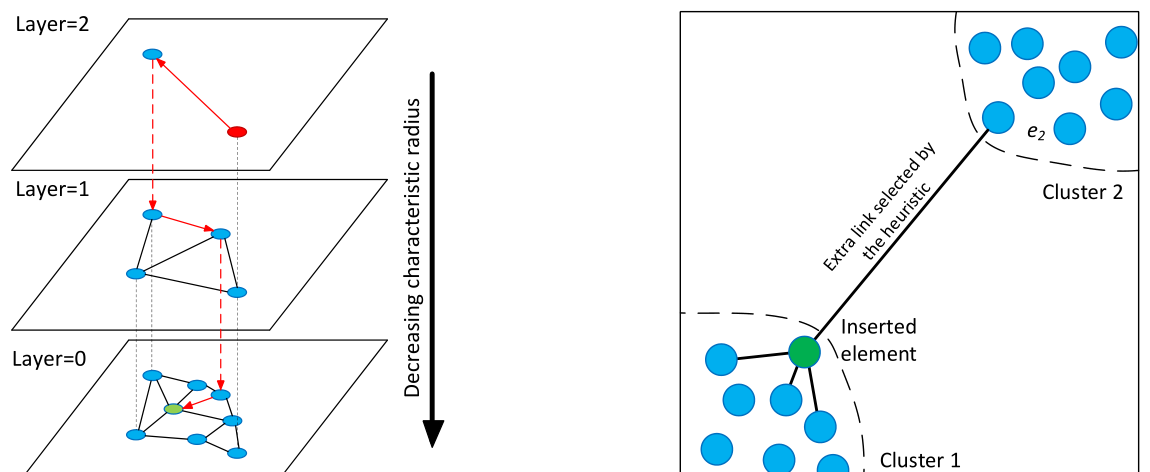

*Malkov, Yashunin, 2016. HNSW: слои графа как автострады и улицы. Milvus строит такой индекс сам, поэтому поиск приближённый: быстрый, но совпадает с перебором не на все сто процентов*

In [83]:
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
if os.getenv("MILVUS_DB"):
    if os.environ["MILVUS_DB"] not in client.list_databases():
        client.create_database(os.environ["MILVUS_DB"])
    client.use_database(os.environ["MILVUS_DB"])
client.get_server_version(), client.list_collections()

('2.6.24', ['lines', 'facts'])

In [84]:
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    rows = [{"id": i, "vector": v.tolist(), **c} for i, (c, v) in enumerate(zip(chunks, vectors))]
    for i in range(0, len(rows), 1000):
        client.insert(name, rows[i:i+1000])

    client.flush(name)
    return client.get_collection_stats(name)
    


In [85]:
def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]

    return [{**h['entity'], "id": h["id"], "score": round(h["distance"], 4)} for h in hits ]
    


In [86]:
index_to_milvus("lines", line_chunks, line_vecs), client.describe_index("lines", "vector")

({'row_count': 6279},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 6279,
  'indexed_rows': 6279,
  'pending_index_rows': 0,
  'state': 'Finished'})

In [87]:
pd.DataFrame(search_milvus("lines", tasks[0]["question"], 3))[["score", "url", "section", "text"]]

,score,url,section,text
0,0.7123,http://arxiv.org/abs/2506.06962v3,AR-RAG: Autoregressive Retrieval Augmentation ...,"Specifically, as generation unfolds, AR-RAG le..."
1,0.6919,http://arxiv.org/abs/2506.06962v3,AR-RAG: Autoregressive Retrieval Augmentation ...,This progressive retrieval refinement mechanis...
2,0.6900,http://arxiv.org/abs/2506.06962v3,,Retrieval-augmented generation (RAG) has emerg...


In [88]:
from_numpy = [[i for i, _ in search_numpy(q, line_vecs, 5)] for q in q_vecs]
from_milvus = [[h["id"] for h in hits] for hits in client.search("lines", data=q_vecs.tolist(), limit=5)]
overlap = float(np.mean([len(set(a) & set(b)) / 5 for a, b in zip(from_numpy, from_milvus)]))
round(overlap, 3), sum(a == b for a, b in zip(from_numpy, from_milvus)), len(q_vecs)

(0.525, 1, 40)

In [89]:
pd.DataFrame(search_milvus("lines", "RAG", 5, 'title == "Ragas: Automated Evaluation of Retrieval Augmented Generation"'))[["score", "url", "section", "text"]]

,score,url,section,text
0,0.6072,http://arxiv.org/abs/2309.15217v2,,We introduce **Ragas** ( **R** etrieval **A** ...
1,0.5929,http://arxiv.org/abs/2309.15217v2,,> 1Ragas is available at https://github.com/ e...
2,0.5888,http://arxiv.org/abs/2309.15217v2,Ragas: Automated Evaluation of Retrieval Augme...,We introduce **Ragas** ( **R** etrieval **A** ...
3,0.5757,http://arxiv.org/abs/2309.15217v2,,of retrieval augmented generation systems. We ...
4,0.5726,http://arxiv.org/abs/2309.15217v2,,We have highlighted the need for automated ref...


{'numpy, перебор': 0.09,
 'Milvus, запрос на вызов': 2.11,
 'Milvus, сто запросов пачкой': 0.13}

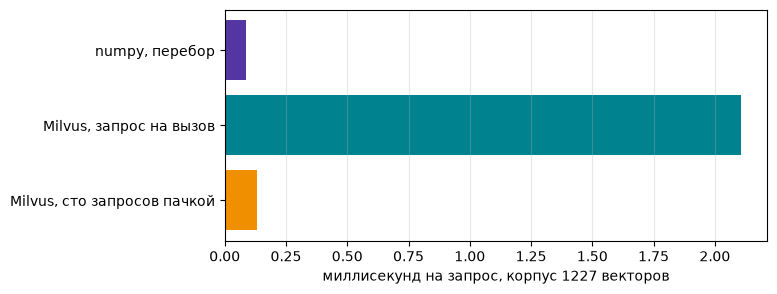

In [63]:
def per_query_ms(fn, n=100):
    started = time.perf_counter()
    fn()
    return (time.perf_counter() - started) * 1000 / n

queries = q_vecs[:100]
speed = {"numpy, перебор": per_query_ms(lambda: [search_numpy(q, line_vecs, 5) for q in queries]),
         "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("lines", data=[q.tolist()], limit=5) for q in queries]),
         "Milvus, сто запросов пачкой": per_query_ms(lambda: client.search("lines", data=queries.tolist(), limit=5))}
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(speed), list(speed.values()), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.invert_yaxis(); ax.set_xlabel(f"миллисекунд на запрос, корпус {len(line_vecs)} векторов"); ax.grid(alpha=0.3, axis="x")
{name: round(ms, 2) for name, ms in speed.items()}

,"numpy, перебор","Milvus, запрос на вызов","Milvus, пачкой"
векторов,,,
1227,0.20,4.98,0.36
50000,9.95,4.98,0.53
200000,39.95,7.84,1.02


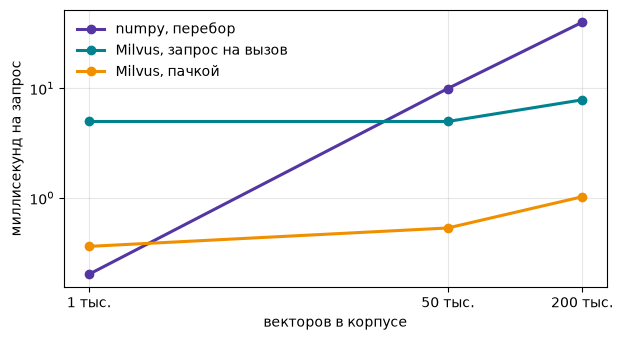

In [64]:
def inflate(vectors, n, noise=0.35, seed=0):
    rng = np.random.default_rng(seed)
    extra = vectors[rng.integers(0, len(vectors), n - len(vectors))]
    extra = extra + noise * rng.standard_normal(extra.shape, dtype=np.float32) / np.sqrt(vectors.shape[1])
    return np.vstack([vectors, extra / np.linalg.norm(extra, axis=1, keepdims=True)])

def wait_index(name, seconds=180):
    for _ in range(seconds):
        info = client.describe_index(name, "vector")
        if info.get("state") == "Finished" and info.get("pending_index_rows", 0) == 0:
            return True
        time.sleep(1)
    return False

scale_rows = []
for n in (len(line_vecs), 50_000, 200_000):
    big = inflate(line_vecs, n)
    if client.has_collection("scale"):
        client.drop_collection("scale")
    client.create_collection("scale", dimension=big.shape[1], metric_type="COSINE")
    for i in range(0, n, 5000):
        client.insert("scale", [{"id": i + j, "vector": v} for j, v in enumerate(big[i:i + 5000].tolist())])
    client.flush("scale")
    wait_index("scale")
    client.search("scale", data=[q_vecs[0].tolist()], limit=5)
    probe = q_vecs[:50]
    scale_rows.append({"векторов": n,
                       "numpy, перебор": per_query_ms(lambda: [search_numpy(q, big, 5) for q in probe], 50),
                       "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("scale", data=[q.tolist()], limit=5) for q in probe], 50),
                       "Milvus, пачкой": per_query_ms(lambda: client.search("scale", data=probe.tolist(), limit=5), 50)})
client.drop_collection("scale")
scale = pd.DataFrame(scale_rows).set_index("векторов")
ax = scale.plot(figsize=(7, 3.6), marker="o", lw=2.2, logx=True, logy=True, color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.set_xticks(list(scale.index)); ax.set_xticklabels([f"{n / 1000:.0f} тыс." for n in scale.index]); ax.minorticks_off()
ax.set_ylabel("миллисекунд на запрос"); ax.set_xlabel("векторов в корпусе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
ax.figure.savefig("img/scale.png", dpi=150, bbox_inches="tight")
scale.round(2)

## Спринт 5. RAG-ответ и деньги

Найденные куски кладём в контекст с номерами и просим модель отвечать только по ним, ссылаться на номер источника и честно писать `NOT_FOUND`, если ответа в источниках нет. Правота проверяется как на первом семинаре: нормализованный эталон должен содержаться в ответе.

Дырка: `rag_answer`. После неё два замера на сорока вопросах. Первый: пять конфигураций, с RAG и без, на трёх ярусах моделей, и наша картинка «деньги против качества». Второй: сколько кусков класть в контекст. Recall с ростом k выходит на плато, а счёт за контекст растёт линейно, поэтому k выбирают по кривой, а не на глаз.

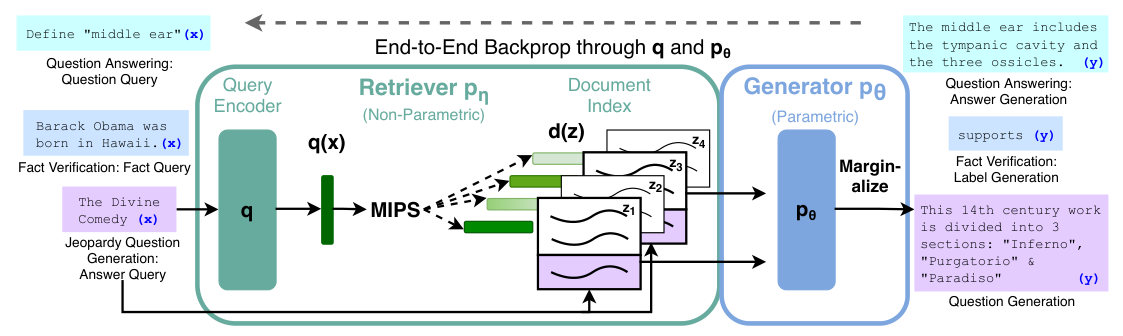

*Lewis et al., 2020. Оригинальная схема RAG: поиск подкладывает куски генератору. У нас то же самое, только через промпт и без обучения*

In [90]:
RAG_SYSTEM = ("Answer the question using only the numbered sources. Cite the source number like [2]. "
              "If the sources do not contain the answer, reply exactly NOT_FOUND. The last line must be FINAL: <short answer>.")
PLAIN_SYSTEM = "Answer the question. If you do not know, reply NOT_FOUND. The last line must be FINAL: <short answer>."

In [91]:
def rag_answer(question, model, k=5, name="lines"):
    hits = search_milvus(name, question, k)
    sources = "\n".join(f"[{i + 1}] ({h['url']}) {h['text']}" for i, h in enumerate(hits))
    before = ledger.mine
    msg = chat([{"role": "system", "content": RAG_SYSTEM},
                {"role": "user", "content": f"Sources\n{sources}\n\nQuestion:{question}"}], model, tag="rag")
    return {"answer": msg.get("content") or "", "hits": hits, "cost": ledger.mine - before}


In [92]:
def plain_answer(question, model):
    before = ledger.mine
    msg = chat([{"role": "system", "content": PLAIN_SYSTEM}, {"role": "user", "content": question}], model, tag="plain")
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before}

def final_answer(text):
    m = re.findall(r"FINAL:\s*(.+)", text or "")
    return m[-1].strip() if m else (text or "").strip()

def is_correct(task, answer):
    return f" {norm(task['answer'])} " in f" {norm(final_answer(answer))} "

def evaluate(fn, sample, config, model, workers=8):
    def one(task):
        try:
            out = fn(task["question"], model)
        except Exception as e:
            out = {"answer": f"ошибка: {e}", "hits": [], "cost": 0.0}
        return {"config": config, "model": model.split("/")[-1], "id": task["id"], "correct": is_correct(task, out["answer"]),
                "found": any(is_gold(h, task) for h in out["hits"]), "refused": "NOT_FOUND" in out["answer"],
                "cost": out["cost"], "answer": final_answer(out["answer"])[:60], "gold": task["answer"]}
    with ThreadPoolExecutor(workers) as pool:
        return pd.DataFrame(list(pool.map(one, sample)))

def report(results):
    g = results.groupby(["config", "model"], sort=False)
    table = g.agg(n=("correct", "size"), accuracy=("correct", "mean"), cost_per_task=("cost", "mean")).reset_index()
    table["cost_per_correct"] = table["cost_per_task"] / table["accuracy"].replace(0, float("nan"))
    return table.round(5)

def money_chart(table, path, baseline=None):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    if baseline:
        ax.axhline(baseline[1] * 100, color=COLORS["grey"], ls="--", lw=1.2)
        ax.annotate(baseline[0], (0.01, baseline[1] * 100 + 1.5), xycoords=("axes fraction", "data"), fontsize=8, color=COLORS["grey"])
    for _, r in table.iterrows():
        color = COLORS["amber"] if "sonnet" in r["model"] else COLORS["teal"] if "haiku" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100), fontsize=8, xytext=(7, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %"); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

out = rag_answer(tasks[0]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

AR-RAG retrieves contextually similar patches from a pre-constructed patch-level database at each generation step [1]. FINAL: contextually similar patches. | эталон: Patch-level k-NN retrievals. | цена, центов: 0.0166


In [98]:
sample = tasks[:40]
results = pd.concat([
    evaluate(plain_answer, sample, "без RAG", MODELS["cheap"]),
    evaluate(plain_answer, sample, "без RAG", MODELS["strong"]),
    evaluate(rag_answer, sample, "RAG, k=10", MODELS["cheap"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["mid"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["strong"]),
], ignore_index=True)
table = report(results)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,без RAG,gpt-4o-mini,40,0.000,0.00004,NaN
1,без RAG,claude-sonnet-4.6,40,0.000,0.00248,NaN
2,"RAG, k=10",gpt-4o-mini,40,0.350,0.00011,0.00031
3,"RAG, k=5",claude-haiku-4.5,40,0.225,0.00128,0.00568
4,"RAG, k=5",claude-sonnet-4.6,40,0.275,0.00380,0.01382


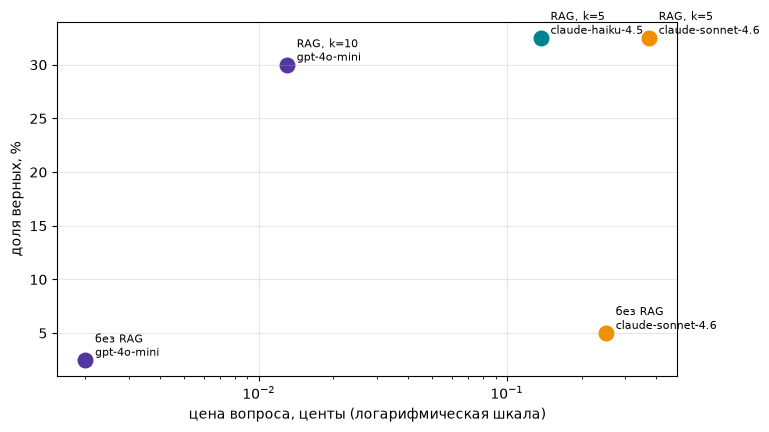

In [69]:
money_chart(table, "img/money_rag.png");

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,k=1,gpt-4o-mini,40,0.175,0.00004,0.00026
1,k=3,gpt-4o-mini,40,0.275,0.00009,0.00032
2,k=5,gpt-4o-mini,40,0.300,0.00013,0.00042
3,k=10,gpt-4o-mini,40,0.350,0.00022,0.00064


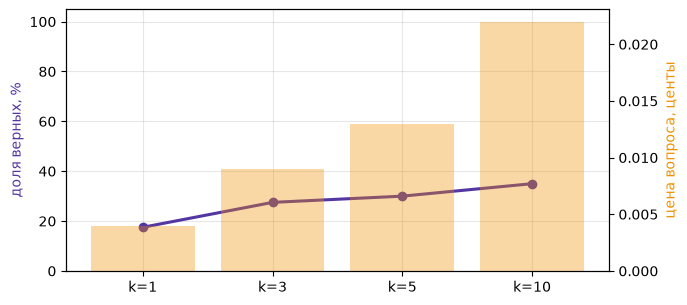

In [70]:
sweep = pd.concat([evaluate(lambda q, m, k=k: rag_answer(q, m, k), sample, f"k={k}", MODELS["cheap"]) for k in (1, 3, 5, 10)], ignore_index=True)
sweep_table = report(sweep)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sweep_table["config"], sweep_table["accuracy"] * 100, marker="o", lw=2.2, color=COLORS["violet"]); ax.set_ylabel("доля верных, %", color=COLORS["violet"])
ax2 = ax.twinx(); ax2.bar(sweep_table["config"], sweep_table["cost_per_task"] * 100, alpha=0.35, color=COLORS["amber"]); ax2.set_ylabel("цена вопроса, центы", color=COLORS["amber"])
ax.set_ylim(0, 105); ax.grid(alpha=0.3)
sweep_table

## Спринт 6. Разбор провалов

У RAG две половины, и ломаются они по-разному. Поиск мог не найти нужный кусок. А мог найти, но модель ответила неверно или отказалась. Чинятся эти случаи в разных местах, поэтому первым делом раскладываем ошибки на две кучки.

Дальше три приёма. Гибрид: вектор ловит смысл, поиск по словам ловит точные имена и числа, слияние рангов RRF берёт лучшее от обоих. Проверим его на обеих нарезках: и там, где вектору тяжело, и там, где он уже хорош. Отказ: десять вопросов, ответа на которые в корпусе нет, и подсчёт, сколько раз система честно сказала `NOT_FOUND`. Порог близости: у неотвечаемых вопросов лучший кусок заметно дальше, и это дешёвый сигнал для отказа ещё до вызова модели.

Дырка: `rrf`. Чекпоинт: две кучки ошибок, recall до и после гибрида, гистограмма близостей.

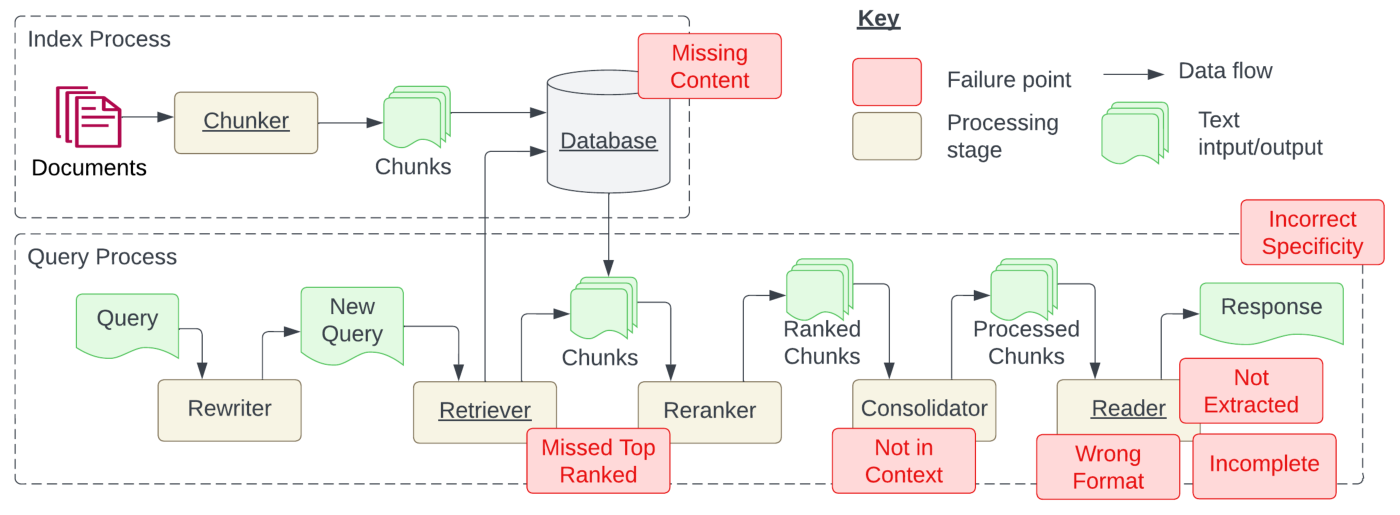

*Barnett et al., 2024. Семь точек отказа RAG из боевых систем: половина до генерации, половина в ней. Мерить надо обе*

In [96]:
def diagnose(results):
    wrong = results[~results["correct"] & results["config"].str.startswith("RAG")]
    return wrong.groupby("model").agg(не_нашли=("found", lambda s: int((~s).sum())), нашли_но_ответ_неверный=("found", "sum"))

diagnose(results)

,не_нашли,нашли_но_ответ_неверный
model,,
claude-haiku-4.5,19,3
claude-sonnet-4.6,19,1
gpt-4o-mini,16,2


In [97]:
results[~results["correct"] & (results["config"] == "RAG, k=5")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
90,claude-haiku-4.5,Patch-level k-NN retrievals.,AR-RAG retrieves the top-K most relevant patch...,False
91,claude-haiku-4.5,DAiD and FAiD.,The two parallel frameworks for AR-RAG are DAi...,False
92,claude-haiku-4.5,Model-predicted patch distribution with retrie...,NOT_FOUND,False
93,claude-haiku-4.5,"Over-copying, stylistic bias, and hallucinatio...",The sources do not contain information about w...,False
94,claude-haiku-4.5,By encoding real-world images into latent patc...,NOT_FOUND,False
95,claude-haiku-4.5,Already-generated surrounding patches.,The sources do not specify what AR-RAG uses as...,False
96,claude-haiku-4.5,6.67 FID.,NOT_FOUND,False
98,claude-haiku-4.5,Multi-scale convolution operations.,FAiD refines retrieved patch features using pa...,False
99,claude-haiku-4.5,It may not directly apply to continuous diffus...,AR-RAG cannot be directly applied to continuou...,False
100,claude-haiku-4.5,10^9 vs 10 bits/s,The fundamental processing gap is the bottlene...,False


In [84]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

In [85]:
def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)

    return sorted(scores, key=scores.get, reverse=True)[:k]
        


,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.18,0.32
1,по 400 символов,только слова,0.30,0.42
2,по 400 символов,гибрид RRF,0.25,0.38
3,по строкам,только вектор,0.18,0.28
4,по строкам,только слова,0.30,0.45
5,по строкам,гибрид RRF,0.28,0.42


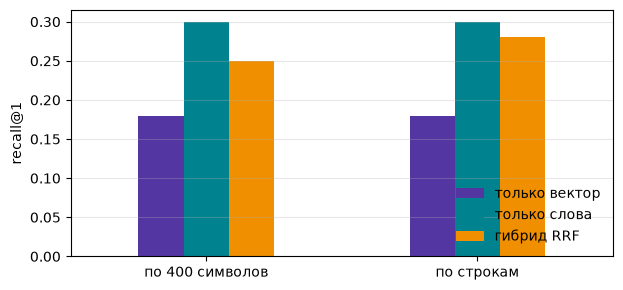

In [86]:
def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@1")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@1"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

In [67]:
UNANSWERABLE = ["Who won the Nobel Prize in Literature announced in October 2026?", "Which team won the 2026 World Series in baseball?",
                "Who won the 2026 Formula One World Drivers' Championship?", "Which country won the Eurovision Song Contest 2027?",
                "Who won the United States Senate election in Maine held on November 3, 2026?", "Which film won the Palme d'Or at the 2027 Cannes Film Festival?",
                "What was the magnitude of the earthquake that struck Lisbon in December 2026?", "Who won the Nobel Peace Prize announced in October 2026?",
                "Which company first reached a ten trillion dollar valuation in November 2026?", "Who won the 2026 World Chess Championship match in December 2026?"]
refusals = [rag_answer(q, MODELS["cheap"]) for q in UNANSWERABLE]
sum("NOT_FOUND" in r["answer"] for r in refusals), [final_answer(r["answer"])[:40] for r in refusals if "NOT_FOUND" not in r["answer"]]

(10, [])

In [87]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(top_answerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["teal"], label="ответ в корпусе есть")
ax.hist(top_unanswerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["red"], label="ответа в корпусе нет")
ax.set_xlabel("близость лучшего куска к вопросу"); ax.set_ylabel("вопросов"); ax.legend(frameon=False); ax.grid(alpha=0.3)
round(float(np.median(top_answerable)), 3), round(float(np.median(top_unanswerable)), 3)

NameError: name 'refusals' is not defined

## Спринт 7. Память агента

У модели памяти нет: помнит ваш код, который кладёт нужное в контекст. Сегодня собираем обе памяти из четвёртой лекции. Эпизодическая: журнал всех реплик в файле, в контекст он не идёт. Семантическая: короткие факты о пользователе, которые дешёвая модель извлекает из диалога отдельным вызовом. Она возвращает обновлённый список целиком, поэтому «переехал», «передумал», «больше не интересуюсь» заменяют старый факт, а не ложатся рядом с ним.

Факты лежат там же, где знания: в Milvus, отдельной коллекцией. К вопросу достаём не все факты, а три ближайших. В контекст идут системный промпт, эти факты, найденные куски корпуса и окно последних реплик. Вся остальная история остаётся в журнале.

Память помогает и поиску. «Что нового в моих темах?» без фактов не ищется никак, а факты, приклеенные к каждому запросу, портят конкретные вопросы: к вопросу про футбол подмешивается хоккей. Поэтому ищем дважды, по самому вопросу и по вопросу с фактами, и сливаем два списка уже знакомым `rrf`. Искать имеет смысл только на вопросы: на «привет, я Лена» база вернёт пять случайных строк, и модель послушно начнёт их пересказывать. Пока это грубая проверка на вопросительный знак, в восьмом спринте решать будет сама модель.

Две дырки: извлечение фактов и поиск по ним. Чекпоинт: во второй сессии агент знает, кто вы и что вам интересно, устаревший факт заменён, а на графике видно, сколько токенов экономит окно с фактами против «тащим всю историю».

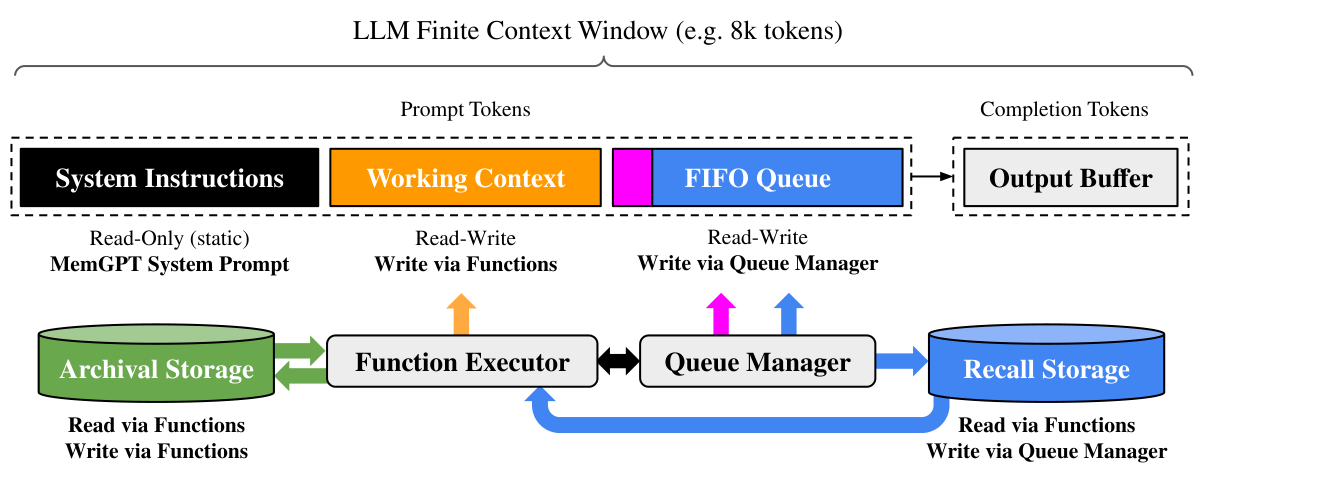

*Packer et al., 2023. MemGPT: контекст как оперативная память, внешние хранилища как диск. В окне живут инструкции, рабочие факты и очередь последних реплик*

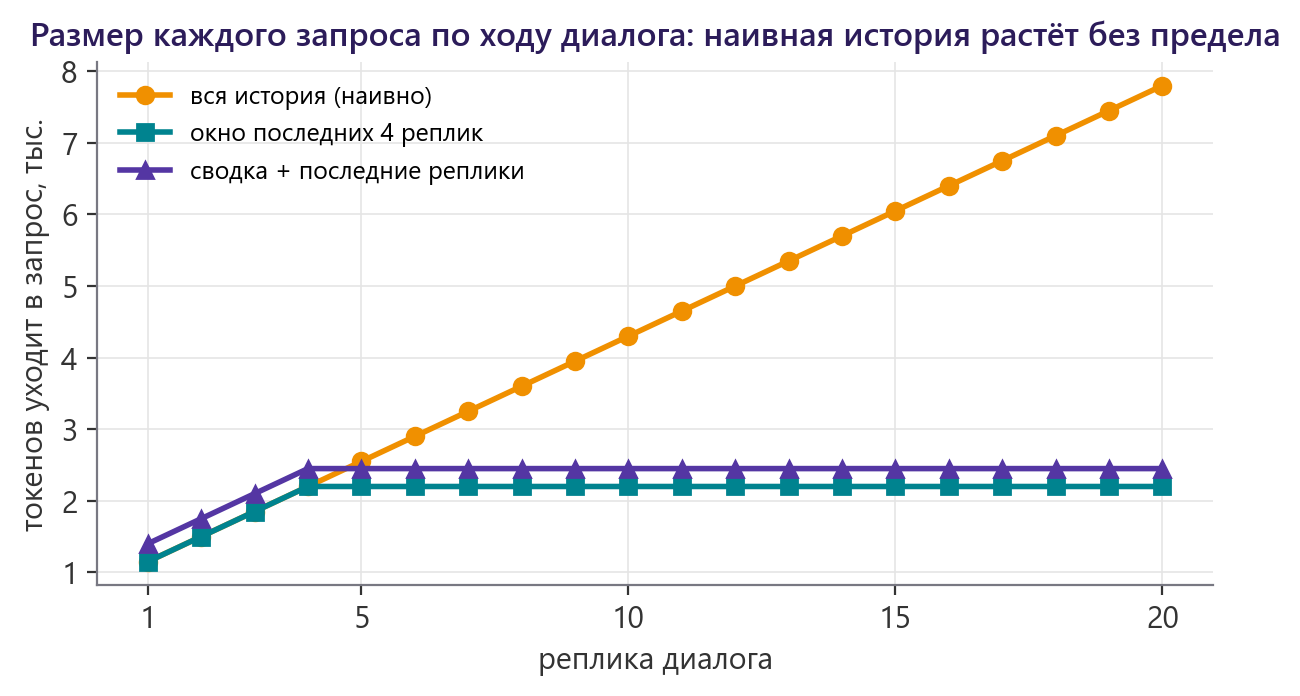

*Из четвёртой лекции: наивная память растёт с каждой репликой, окно и сводка держат запрос плоским*

In [88]:
FACTS_SYSTEM = ("Ты ведёшь память ассистента о пользователе. Верни один JSON-объект вида {\"facts\": [\"...\"]}: полный обновлённый список "
                "коротких фактов о пользователе. Добавь новые устойчивые факты: имя, город, работа, интересы, пожелания к ответам. "
                "Если новый факт отменяет старый, замени старый. Разовые вопросы и мелочи не записывай.")
ASSISTANT_SYSTEM = ("Ты помощник, который отвечает на вопросы о событиях 2026 года по базе знаний. Отвечай на языке пользователя, "
                    "опирайся на источники и на то, что знаешь о пользователе. Источники подобраны автоматически и могут быть не по теме: "
                    "используй только те, что относятся к вопросу. Если в источниках ответа нет, так и скажи.")
JOURNAL, FACTS_FILE = Path("episodes.jsonl"), Path("facts.json")

class Facts(BaseModel):
    facts: list[str] = Field(description="короткие факты о пользователе")

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    cleaned = re.sub(r'(\\["\\/bfnrtu])|\\', lambda e: e.group(1) or "\\\\", m.group(0) if m else "{}")
    return json.loads(cleaned, strict=False)

def known_facts():
    return json.loads(FACTS_FILE.read_text(encoding="utf-8")) if FACTS_FILE.exists() else []

def store_facts(facts):
    FACTS_FILE.write_text(json.dumps(facts, ensure_ascii=False, indent=1), encoding="utf-8")
    if facts:
        index_to_milvus("facts", [{"page": "memory", "section": "", "url": "", "text": f} for f in facts], embed_cached(facts))

def remember_episode(session, role, text):
    with JOURNAL.open("a", encoding="utf-8") as f:
        f.write(json.dumps({"session": session, "time": time.strftime("%Y-%m-%d %H:%M:%S"), "role": role, "text": text}, ensure_ascii=False) + "\n")

for path in (JOURNAL, FACTS_FILE):
    path.unlink(missing_ok=True)
if client.has_collection("facts"):
    client.drop_collection("facts")

In [89]:
def extract_facts(dialog, known):
    prompt = f"Известные факты: {json.dumps(known, ensure_ascii=False)}\n\nДиалог:\n{dialog}"
    msg = chat([{"role": "system", "content": FACTS_SYSTEM}, {"role": "user", "content": prompt}], MODELS['cheap'], tag="memory")
    return Facts.model_validate(json_from(msg["content"])).facts
    


In [90]:
def recall_facts(question, k=3):
    if not client.has_collection("facts"):
        return []
    return [h["text"] for h in search_milvus("facts", question, k)]


In [96]:
def search_with_memory(user_text, facts, k=5):
    plain = search_milvus("lines", user_text, k)
    personal = search_milvus("lines", user_text + " " + " ".join(facts), k) if facts else []
    by_id = {h["id"]: h for h in plain + personal}
    return [by_id[i] for i in rrf([[h["id"] for h in plain], [h["id"] for h in personal]], k)]

def talk(session, history, user_text, mode="память"):
    remember_episode(session, "user", user_text)
    facts = recall_facts(user_text) if mode == "память" else []
    hits = search_with_memory(user_text, facts) if "?" in user_text else []
    sources = "\n".join(f"[{i + 1}] ({h['url']}) {h['text']}" for i, h in enumerate(hits)) or "нет"
    system = ASSISTANT_SYSTEM + ("\nЧто известно о пользователе: " + "; ".join(facts) if facts else "")
    window = history[-4:] if mode == "память" else history
    msg = chat([{"role": "system", "content": system}] + window + [{"role": "user", "content": f"Источники:\n{sources}\n\n{user_text}"}],
               MODELS["cheap"], tag=f"dialog: {mode}")
    answer = msg.get("content") or ""
    history += [{"role": "user", "content": user_text if mode == "память" else f"Источники:\n{sources}\n\n{user_text}"}, {"role": "assistant", "content": answer}]
    remember_episode(session, "assistant", answer)
    return answer

def end_session(history):
    dialog = "\n".join(f"{m['role']}: {m['content'][:400]}" for m in history)
    store_facts(extract_facts(dialog, known_facts()))
    return known_facts()

In [97]:
first = []
print(talk("s1", first, "Привет! Я Лена, продуктовый аналитик из Новосибирска. Слежу за космосом и хоккеем, отвечай коротко."))
print(talk("s1", first, "Что такое AR-RAG?"))
end_session(first)

Привет, Лена! Какой вопрос о событиях 2026 года тебя интересует?
AR-RAG (Autoregressive Retrieval Augmentation for Image Generation) — это метод, который улучшает генерацию изображений, используя подход, основанный на извлечении информации. Он позволяет моделям извлекать релевантные документы или изображения для дополнения их знаний во время генерации. Это помогает создавать более точные и контекстуально уместные изображения, учитывая запросы пользователей.


['Имя: Лена',
 'Город: Новосибирск',
 'Работа: продуктовый аналитик',
 'Интересы: космос, хоккей',
 'Пожелания к ответам: отвечай коротко']

In [98]:
second = []
print(talk("s2", second, "Что такое Retrieval-Augmented Prototype-Guided Foundation Model for Electronic Health Records?"))
print(talk("s2", second, "Хоккей я забросила, теперь слежу за статьями по RAG."))
print(talk("s2", second, "Как Преодолевать малополезные аспекты для поиска сложных ответов? Коротко"))
end_session(second)

Извините, но в предоставленных источниках нет информации о Retrieval-Augmented Prototype-Guided Foundation Model for Electronic Health Records. Если у вас есть другие вопросы или нужна помощь с чем-то другим, дайте знать!
Поняла, Лена! Retrieval-Augmented Generation (RAG) — это подход в области обработки естественного языка, который сочетает в себе генерацию текста и извлечение информации. Он использует внешние источники данных для улучшения качества генерируемого текста, что может быть полезно в различных приложениях, включая медицинские записи.

Если вас интересует, как этот подход может быть применен в контексте электронных медицинских записей, то он может помочь в более точном извлечении информации и генерации отчетов на основе больших объемов данных. Это может улучшить качество медицинского обслуживания и ускорить процесс принятия решений.

Если у вас есть более конкретные вопросы по этой теме или другим аспектам RAG, дайте знать!
Преодоление малополезных аспектов для поиска сложн

['Имя: Лена',
 'Город: Новосибирск',
 'Работа: продуктовый аналитик',
 'Интересы: космос, статьи по RAG',
 'Пожелания к ответам: отвечай коротко']

,prompt,cost
tag,,
dialog: память,2147,0.00063


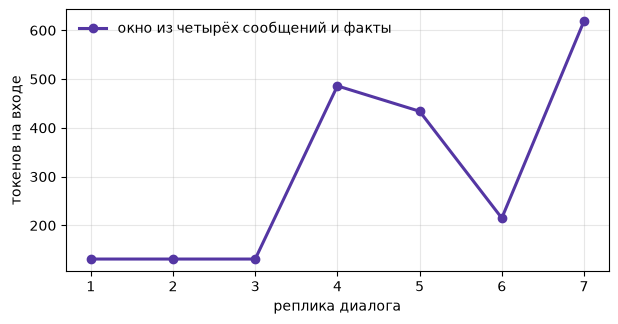

In [99]:
SCRIPT = [t["question"] for t in tasks[40:50]]
for mode in ("память", "вся история"):
    history = []
    for q in SCRIPT:
        talk("bench", history, q, mode)
per_turn = pd.DataFrame([c for c in ledger.calls if c["tag"].startswith("dialog: ")][-2 * len(SCRIPT):])
fig, ax = plt.subplots(figsize=(7, 3.4))
for (tag, part), color in zip(per_turn.groupby("tag", sort=False), [COLORS["violet"], COLORS["amber"]]):
    ax.plot(range(1, len(part) + 1), part["prompt"].values, marker="o", lw=2.2, color=color,
            label={"dialog: память": "окно из четырёх сообщений и факты", "dialog: вся история": "вся история в контексте"}[tag])
ax.set_xlabel("реплика диалога"); ax.set_ylabel("токенов на входе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/memory_tokens.png", dpi=150, bbox_inches="tight")
per_turn.groupby("tag", sort=False).agg(prompt=("prompt", "sum"), cost=("cost", "sum")).round(5)

## Спринт 8. Поиск как инструмент агента

До сих пор поиск делался всегда: пришёл вопрос, нашли куски, ответили. В агенте поиск это инструмент, который модель зовёт сама, когда решит, что ей не хватает знаний. Она может искать несколько раз, уточняя запрос, сузить поиск до одной страницы или не искать вовсе.

Цикл агента берём с первого семинара в сжатом виде. Дырка одна: сам инструмент `knowledge_base` с фильтром по странице. Чекпоинт: те же сорок вопросов двумя способами, «RAG всегда» против «агент решает сам», и итоговая картинка недели. Пунктир на ней это прошлая неделя: поле `agent_ok` в вопросах хранит, ответил ли на вопрос агент с живым поиском по Википедии из первой домашки.

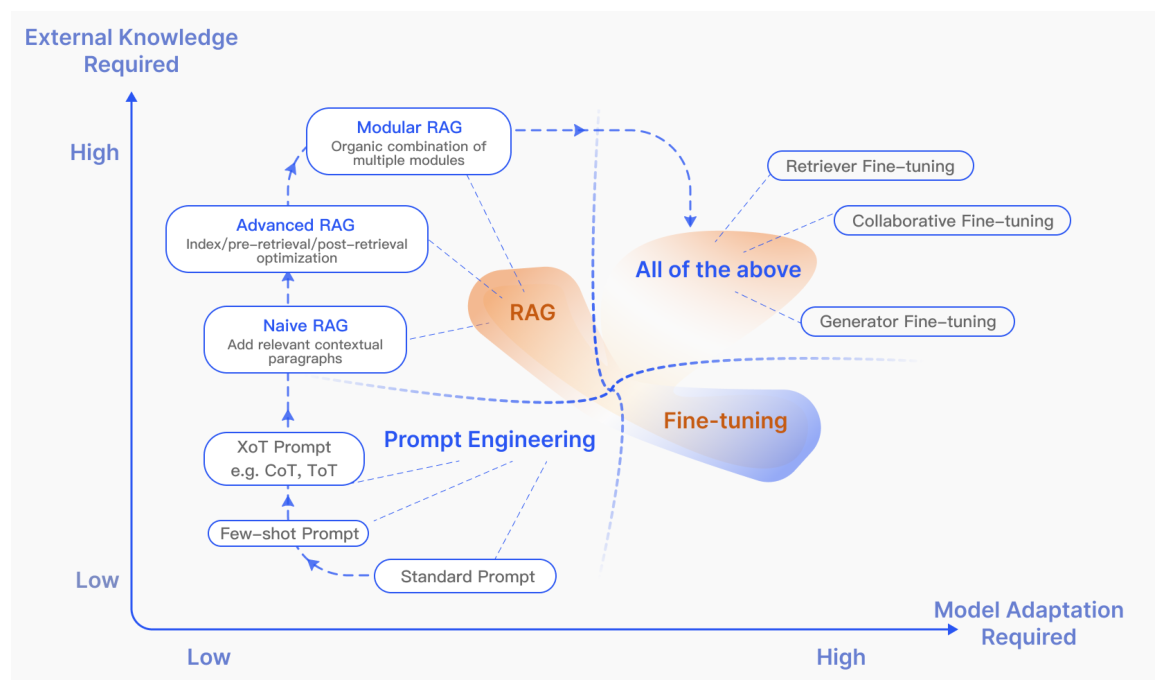

*Gao et al., 2023. Карта приёмов: по вертикали внешние знания, по горизонтали переделка модели. Поиск как инструмент агента это Modular RAG: самый верх карты, а модель мы при этом не трогаем*

In [100]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        result = spec["fn"](**spec["args"].model_validate_json(call["function"]["arguments"]).model_dump())
    except Exception as e:
        result = f"ошибка инструмента {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:3000]}

AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")

def agent(question, model, max_steps=6):
    messages, seen, before = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set(), ledger.mine
    schemas = [t["schema"] for t in TOOLS.values()]
    for step in range(max_steps):
        msg = chat(messages, model, tools=schemas, tag="agent")
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        keys = {(c["function"]["name"], c["function"]["arguments"]) for c in calls}
        if not calls or keys & seen or step == max_steps - 1:
            break
        seen |= keys
        messages += [run_tool(c) for c in calls]
    if calls:
        messages += [{"role": "tool", "tool_call_id": c["id"], "content": "call rejected: answer from what you already have"} for c in calls]
        msg = chat(messages, model, tag="agent")
    searches = sum(m.get("role") == "tool" for m in messages if isinstance(m, dict))
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before, "searches": searches}

class KBArgs(BaseModel):
    query: str = Field(description="short search query in English: names, dates, key terms of the event")
    page: str = Field(default="", description="optional exact page title to search within, for example '2026 in Japan'; empty means all pages")

In [101]:
def knowledge_base(query: str, title: str = "") -> str:
    hits = search_milvus("lines", query, 5, f'title == "{title}"' if title else "")
    if not hits:
        return "nothing found"
    return "\n".join(f"[{h['page']} / {h['section']}] {h['text']}" for h in hits)


In [102]:
register(knowledge_base, KBArgs, "Searches the local knowledge base of RAG papers")
out = agent(tasks[3]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[3]["answer"], "| обращений к базе:", out["searches"], "| цена, центов:", round(out["cost"] * 100, 4))

I currently do not have specific information about the expected support areas from AI in 2026. Please check a reliable source for the most accurate and updated information. 

FINAL: NOT_FOUND | эталон: real-time comprehension and post-visit organization | обращений к базе: 2 | цена, центов: 0.0127


,config,model,n,accuracy,cost_per_task,cost_per_correct
0,"RAG, k=5",gpt-4o-mini,40,0.175,0.00010,0.00058
1,агент с инструментом,gpt-4o-mini,40,0.000,0.00019,NaN


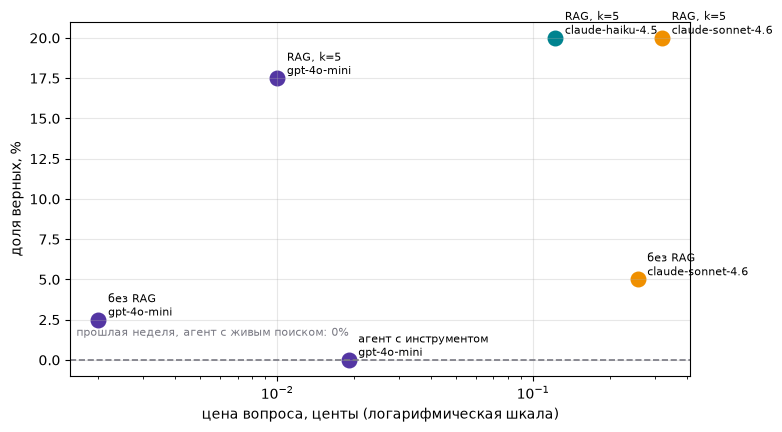

In [103]:
agent_results = evaluate(agent, sample, "агент с инструментом", MODELS["cheap"])
always = results[(results["config"] == "RAG, k=5") & (results["model"] == "gpt-4o-mini")]
final_table = report(pd.concat([results, agent_results], ignore_index=True))
last_week = float(np.mean([t["agent_ok"] for t in sample]))
money_chart(final_table, "img/money_all.png", baseline=(f"прошлая неделя, агент с живым поиском: {last_week:.0%}", last_week))
report(pd.concat([always, agent_results], ignore_index=True))

In [80]:
ledger.table(), round(ledger.total, 3)

(                                            calls  prompt  completion     cost
 tag                 model                                                     
 agent               gpt-4o-mini                88   30459        2863  0.00629
 dialog: вся история gpt-4o-mini                10   16315         424  0.00193
 dialog: память      gpt-4o-mini                15    6796         777  0.00149
 embed               text-embedding-3-small    112   73205           0  0.00146
 memory              gpt-4o-mini                 2     754         105  0.00018
 plain               claude-sonnet-4.6          40    2296        2465  0.04386
                     gpt-4o-mini                40    2254         368  0.00056
 rag                 claude-haiku-4.5           40   13243        2471  0.02560
                     claude-sonnet-4.6          40   13283        2300  0.07435
                     gpt-4o-mini               211   60350        6939  0.01322,
 0.169)

## Дополнение. Тот же конвейер на PDF

Для тех, кто закончил раньше, и для домашки на своём корпусе. PDF это картинка с буквами: текст из него достаётся постранично, колонки и таблицы превращаются в поток строк. Ниже самый простой путь через `pypdf`: страница это кусок, имя файла и номер страницы едут метаданными. Корпусом служат материалы самого курса: пятая и шестая лекции и задание первой недели.

Посмотрите, во что превратилась таблица с критериями оценки: заголовок и строки идут подряд без границ, и нарезка по символам легко оторвёт одно от другого. Для серьёзных документов берут разборщики структуры вроде Docling и Unstructured, о них говорили на шестой лекции.

In [81]:
from pypdf import PdfReader

def pdf_chunks(path):
    reader = PdfReader(str(path))
    pages = [(n + 1, " ".join((p.extract_text() or "").split())) for n, p in enumerate(reader.pages)]
    return [{"page": path.name, "section": f"стр. {n}", "url": "", "text": text} for n, text in pages if len(text) >= 80]

pdf = [c for path in sorted((DATA / "pdf").glob("*.pdf")) for c in pdf_chunks(path)]
index_to_milvus("course", pdf, embed_cached([emb_text(c) for c in pdf]))
save_cache()
len(pdf), next(c["text"][c["text"].find("Критерий Баллы"):][:420] for c in pdf if "Критерий Баллы" in c["text"])

(55,
 'Критерий Баллы Репозиторий запускается с чистого клона, ключа в истории нет 2 Датасет по требованиям, проверка свежести приложена, Sonnet не выше 20 процентов 2 Агент с поиском и чтением страницы, инструменты с тестами 2 Таблица со всеми обязательными строками и картинка 2 Два разобранных провала и честный вывод по тезису 2 Бонус: каскад поверх лучшего агента, строка в таблице и точка на картинке +1 Бонус: второй ист')

In [82]:
COURSE_SYSTEM = RAG_SYSTEM.replace("Answer the question", "Answer in Russian")
for q in ["Что такое RRF и зачем он нужен?", "Какая доля верных ответов Sonnet допустима по критерию свежести в домашнем задании?", "Сколько баллов в домашнем задании дают за два разобранных провала?"]:
    hits = search_milvus("course", q, 3)
    sources = "\n".join(f"[{i + 1}] ({h['page']}, {h['section']}) {h['text'][:3000]}" for i, h in enumerate(hits))
    msg = chat([{"role": "system", "content": COURSE_SYSTEM}, {"role": "user", "content": f"Sources:\n{sources}\n\nQuestion: {q}"}], MODELS["cheap"], tag="pdf")
    print(q, "\n ", " ".join((msg.get("content") or "").split())[:300], "\n  источники:", [(h["page"], h["section"]) for h in hits], "\n")

Что такое RRF и зачем он нужен? 
  RRF (Ranked Reciprocal Fusion) — это метод, который объединяет ранги из разных списков результатов поиска, позволяя учитывать как смысловые, так и точные совпадения. Он используется для того, чтобы каждый способ поиска извлекал то, что умеет, а слияние собирало лучшее в одной строке, что позволяет у 
  источники: [('lecture06.pdf', 'стр. 14'), ('lecture06.pdf', 'стр. 19'), ('lecture05.pdf', 'стр. 24')] 

Какая доля верных ответов Sonnet допустима по критерию свежести в домашнем задании? 
  Доля верных ответов Sonnet 4.6 должна быть не выше 20 процентов по критерию свежести в домашнем задании [3]. FINAL: 20 процентов. 
  источники: [('homework01.pdf', 'стр. 1'), ('lecture06.pdf', 'стр. 17'), ('homework01.pdf', 'стр. 2')] 

Сколько баллов в домашнем задании дают за два разобранных провала? 
  В домашнем задании за два разобранных провала дают 2 балла [2]. FINAL: 2 балла. 
  источники: [('homework01.pdf', 'стр. 4'), ('homework01.pdf', 'стр. 3'), ('lectur